In [1]:
import os
import re

import openai

from tqdm import tqdm
import pickle

import numpy as np
import pandas as pd
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity



In [ ]:
def generate_gpt4_response(content, print_output=False):
    response = openai.chat.completions.create(
        model="gpt-4o",
        messages=[
            {"role": "user", "content": content}
        ],
        temperature=0,
        top_p=0.1,
        n=1,
        # max_tokens=2000,  # Uncomment if you want to limit output length
        # stop=["###"],    # Uncomment if you want to specify stop tokens
    )

    if print_output:
        print(response)

    # Extract and return the first response
    return response.choices[0].message.content

In [3]:
def save_to_pickle(obj, filepath):
    with open(filepath, 'wb') as f:
        pickle.dump(obj, f)

def load_from_pickle(filepath):
    with open(filepath, 'rb') as f:
        return pickle.load(f)

In [4]:
def extract_clusters(folder_path):
    cluster_dict = {}
    
    # Retrieve all txt files in the folder
    txt_files = [f for f in os.listdir(folder_path) if f.endswith('.txt')]
    
    for file_name in txt_files:
        file_path = os.path.join(folder_path, file_name)
        
        with open(file_path, 'r', encoding='utf-8') as file:
            content = file.read()
            
            # Extract cluster id
            cluster_match = re.search(r'Cluster (\d+) Terms:', content)
            if cluster_match:
                cluster_id = int(cluster_match.group(1))
                
                # Extract terms
                terms_match = re.search(r'Cluster \d+ Terms:\n(.+?)\n\n', content, re.DOTALL)
                if terms_match:
                    terms = terms_match.group(1).split('\n')
                    cluster_dict[cluster_id] = terms
    
    return cluster_dict


def check_abbreviation(cluster_dict, abbr_len=10):
    cluster_dict_abbr = {}
    for cid in cluster_dict.keys():
        keywords = cluster_dict[cid]
        average_length = sum(len(s) for s in keywords) / len(keywords)

        is_shorter_than_10 = average_length < abbr_len
        if is_shorter_than_10:
            cluster_dict_abbr[cid] = keywords
    return cluster_dict_abbr
    
            
def remove_abbreviation(cluster_dict, abbr_list):
    cluster_dict_cleaned = {}
    for cid in cluster_dict.keys():
        keywords = cluster_dict[cid]
        if cid not in abbr_list:
            cluster_dict_cleaned[cid] = keywords
    return cluster_dict_cleaned

# def remove_not_coherent_cluster(cluster_dict):
#     cluster_dict_cleaned = {}
#     for cid in tqdm(sorted(cluster_dict.keys())):
#         # print(cid)
#         keywords = cluster_dict[cid]
#         prompt = f"""
# {keywords}
# Please help determine if these terms focus on a coherent topic or not. Answer "yes" or "no" only.
# """
#         response = generate_gpt4_response(prompt)
#         response = response.strip(".").lower()
#         # print(response)
        
#         if response == 'yes':
#             cluster_dict_cleaned[cid] = [keywords]
            
#     return cluster_dict_cleaned

In [5]:
from pydantic import BaseModel, validator
from typing import Dict, List, Optional, Union
from tqdm import tqdm

openai_client = openai.OpenAI(api_key=openai.api_key)
# Corrected model for GPT response
class GPTClusterResponse(BaseModel):
    label: str
    subtopics: List[List[str]]

    @validator('label')
    def validate_label(cls, v):
        v = v.strip().lower()
        if v not in {"yes", "no"}:
            raise ValueError("label must be 'yes' or 'no'")
        return v

    @validator('subtopics')
    def validate_subtopics(cls, v, values):
        label = values.get('label')
        if label == "yes":
            if v is None or (isinstance(v, dict) and len(v) == 0):
                return {}
            else:
                raise ValueError("If label is 'yes', subtopics must be an empty dict or omitted")
        return v

def generate_gpt4_structured_response(content, print_output=False):
    response = openai_client.responses.parse(
        model="gpt-4o",
        input=[
            {
                "role": "user",
                "content": content,
            },
        ],
        text_format=GPTClusterResponse,
    )

    parsed_response = response.output_parsed

    if print_output:
        print(parsed_response)

    # Extract and return the first response
    return parsed_response

# Main clustering function
def break_cluster(cluster_dict: Dict[str, List[str]]) -> Dict[str, List[str]]:
    cluster_dict_cleaned = {}

    for cid in tqdm(sorted(cluster_dict.keys())):
        keywords = cluster_dict[cid]
        prompt = f"""
{keywords}
Please help determine if these terms focus on a coherent topic or not. Answer strictly in the following JSON format:

If the terms form a coherent topic:
{{
  "label": "yes",
  "subtopics": []
}}

If not:
{{
  "label": "no",
  "subtopics": [
    [list of keywords for topic 1],
    [list of keywords for topic 2],
    ...
  ]
}}
"""

        # parsed = generate_gpt4_structured_response(prompt)

        try:
            parsed = generate_gpt4_structured_response(prompt)
            # print(type(parsed))
            # print(parsed)

            if parsed.label == "yes":
                cluster_dict_cleaned[cid] = [keywords]
            elif parsed.label == "no":
                # for i, sublist in enumerate(parsed.subtopics):
                cluster_dict_cleaned[cid] = parsed.subtopics

        except Exception as e:
            print(f"[Validation error] Cluster '{cid}': {e}")
            continue

    return cluster_dict_cleaned


/tmp/ipykernel_1175173/1872494862.py:11: PydanticDeprecatedSince20: Pydantic V1 style `@validator` validators are deprecated. You should migrate to Pydantic V2 style `@field_validator` validators, see the migration guide for more details. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.8/migration/
  @validator('label')
/tmp/ipykernel_1175173/1872494862.py:18: PydanticDeprecatedSince20: Pydantic V1 style `@validator` validators are deprecated. You should migrate to Pydantic V2 style `@field_validator` validators, see the migration guide for more details. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.8/migration/
  @validator('subtopics')


In [6]:
def load_keywords_sheet(file_path):
    sheet_name = "New Test Cleaned Keywords + Pap"
    try:
        df = pd.read_excel(file_path, sheet_name=sheet_name)
        return df
    except Exception as e:
        print(f"Error loading sheet: {e}")
        return None


def count_papers_per_keyword(df, topic_dict, year_col="Year", keyword_col="Keywords"):
    from collections import defaultdict, Counter
    topic_year_count = defaultdict(int)

    # Preprocess topic terms for faster matching (optional: lowercasing)
    topic_terms = {}
    for cid, keyword_list in topic_dict.items():
        for idx, keywords in enumerate(keyword_list):
            topic_terms[f"{cid}-{idx}"] = set(keyword.lower() for keyword in keywords)
        
    dict_keywords = Counter()
    for _, row in df.iterrows():
        keywords = row.get(keyword_col)

        if pd.isna(keywords):
            continue

        # Lowercase + split if keywords are separated (adjust if needed)
        keyword_list = [kw.strip().lower() for kw in str(keywords).split(",")]
        for keyword in keyword_list:
            dict_keywords[keyword] += 1

    topic_keyword_count = defaultdict(dict)
    for topic_id, term_set in topic_terms.items():
        for keyword in term_set:
            if keyword in dict_keywords:
                topic_keyword_count[topic_id][keyword] = dict_keywords[keyword]
        
        
    return topic_keyword_count

def convert_counts_to_proportions(topic_keyword_count):
    topic_keyword_proportion = {}

    for topic_id, keywords in topic_keyword_count.items():
        total = sum(keywords.values())
        if total == 0:
            topic_keyword_proportion[topic_id] = {kw: 0.0 for kw in keywords}
        else:
            topic_keyword_proportion[topic_id] = {
                kw: count / total for kw, count in keywords.items()
            }

    return topic_keyword_proportion


In [7]:
"""
{'1-1':{'keyword1':0.01, ....}}
"""
def generate_name(keyword_distribution, domain='method'):

    if len(keyword_distribution)==1:
        name = list(keyword_distribution.keys())[0]

    if domain=='method':
        prompt = f"""
Please use 1 precise and succinct phrase in no more than 3 words to summarize the main topic of the following list of keywords in the methodology domain based on their distribution:
{keyword_distribution}
"""
    else:
        prompt = f"""
Please use 1 precise and succinct phrase in no more than 3 words to summarize the main topic of the following list of keywords in the health domain based on their distribution:
{keyword_distribution}
"""
        
    name = generate_gpt4_response(prompt).rstrip('.')
    return name

def get_top_k_similar(embedding, embeddings, names, k=5):
    embedding = embedding.reshape(1, -1)
    similarities = cosine_similarity(embedding, embeddings)[0]
    top_k_indices = np.argsort(similarities)[::-1][:k]
    top_k_names = [names[i] for i in top_k_indices]
    top_k_scores = [similarities[i] for i in top_k_indices]
    return top_k_names, top_k_scores



def check_existing_names_suitability(name, similar_names, keyword_distribution, domain, max_retries=5):    
    phrase_str = ''
    for idx, s_name in enumerate(similar_names):
        phrase_str += f'{idx}. {s_name}\n'

    if domain == 'method':
        prompt = f"""
        Please check if any of these phrases can summarize the main topic of the following list of keywords in the methodology domain based on their distribution:
        {keyword_distribution}
        Here is the list of phrases:
        {phrase_str}
    
        Return the ID only of the top 1 suitable phrase without providing the rationale. If none, return none only. 
        """
    else:
        prompt = f"""
        Please check if any of these phrases can summarize the main topic of the following list of keywords in the health domain based on their distribution:
        {keyword_distribution}
        Here is the list of phrases:
        {phrase_str}
    
        Return the ID only of the top 1 suitable phrase without providing the rationale. If none, return none only. 
        """
    for attempt in range(max_retries):
        response = generate_gpt4_response(prompt).strip().rstrip('.').lower()

        if response[:4] == 'none':
            return name
        elif response[0].isdigit():
            idx = int(response[0])
            if 0 <= idx < len(similar_names):
                return similar_names[idx]
        
        # Retry on invalid response
        print(f"Invalid response '{response}', retrying ({attempt+1}/{max_retries})...")

    # Fallback if no valid response is received
    return name
    
    
def topic_naming(dict_topic_keyword, domain, similarity_threshold=0, k=3):

    embeddings = np.empty((0, 768))  # Adjust dimension to your embedding size
    names = []
    dict_topic_id2name = {}
    for tid, keyword_distribution in tqdm(dict_topic_keyword.items()):

        name = generate_name(keyword_distribution, domain)
        
        embedding = generate_embeddings_in_batches(name, batch_size=1)[0, :]  # shape (768,)
        if name in names:
            dict_topic_id2name[tid] = name
            continue
        if len(names) == 0:
            names.append(name)
            embeddings = np.vstack([embeddings, embedding])
            dict_topic_id2name[tid] = name
        else:
            top_k_names, top_k_scores = get_top_k_similar(embedding, embeddings, names, k=k)
            # print(top_k_names, top_k_scores)
            
            if top_k_scores[0] < similarity_threshold:  # Check if it's dissimilar enough to be new
                names.append(name)
                embeddings = np.vstack([embeddings, embedding])
                dict_topic_id2name[tid] = name
            else:
                selected_name = check_existing_names_suitability(name, top_k_names, keyword_distribution, domain)
                # print('selected_name', selected_name)
                if selected_name not in names:
                    names.append(selected_name)
                    embeddings = np.vstack([embeddings, embedding])
                dict_topic_id2name[tid] = selected_name
    return dict_topic_id2name
    


In [8]:
# from enum import Enum
# from pydantic import BaseModel

# import json


# class SetRelation(Enum):
#     SUPERSET = "Superset"
#     EQUAL = "Equal"
#     SUBSET = "Subset"
#     NO_OVERLAP = "NoOverlap"


# class PairwiseRelation(BaseModel):
#     topic_a: str
#     topic_b: str
#     relation: SetRelation




# def extract_topic_relationship_o3mini(topic_a, topic_b):
#     system_prompt = (
#         """
#         Determine the relationship between Topic A and Topic  B. Use the following relationship labels:
#         - Superset: Topic B is a Topic A.
#         - Subset: Topic A is a Topic B.
#         - Equal: Topic A and B are synonyms
#         - NoOverlap: The two topics are conceptually distinct.
        
        
#         Return your response in the specified format.
#         """
#     )



#     user_prompt = f"Topic A: {topic_a}\nTopic B: {topic_b}"

#     response = openai_client.beta.chat.completions.parse(
#         model="o3-mini",
#         messages=[
#            {"role": "system", "content": system_prompt},
#            {"role": "user", "content": user_prompt}
#         ],
#         response_format=PairwiseRelation,
#     )
#     raw_json = response.choices[0].message.content
#     parsed = json.loads(raw_json)
#     return PairwiseRelation(**parsed)


In [9]:
# def extract_topic_relationship(topic_a, topic_b):
#     prompt = (
#         f"""
#         Determine the relationship between Topic A and Topic  B. Use the following relationship labels:
#         Superset: Topic B is a Topic A.
#         Subset: Topic A is a Topic B.
#         Equal: Topic A and B are synonyms
#         NoOverlap: The two topics are conceptually distinct.
        
#         Here are the topics:
#         Topic A: {topic_a}\nTopic B: {topic_b}
        
#         Return the label only.
#         """
#     )

#     response = generate_gpt4_response(prompt)
#     return response.strip(".").lower()

In [10]:

def combine_topic_w_same_name(original_dict):
    from nltk.stem import PorterStemmer
    from collections import defaultdict
    stemmer = PorterStemmer()

    unique_values = defaultdict(list)
    for k, v in original_dict.items():
        stemmed = ' '.join([stemmer.stem(word.lower()) for word in v.split()])
        unique_values[stemmed].append(k)
            

    return unique_values
    

In [11]:
from sentence_transformers import SentenceTransformer, util
from typing import List
import numpy as np

embedder = SentenceTransformer('all-mpnet-base-v2')

def generate_embeddings_in_batches(
    texts,
    batch_size= 1024
):
    """
    Generate sentence embeddings in batches.
    
    Args:
        texts (List[str]): List of input text strings.
        model_name (str): Pretrained SentenceTransformer model name.
        batch_size (int): Number of texts to process per batch.
    
    Returns:
        np.ndarray: Array of embeddings.
    """
    embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        batch_embeddings = embedder.encode(batch, convert_to_numpy=True)
        embeddings.append(batch_embeddings)

    return np.vstack(embeddings)


In [12]:

def compute_pairwise_cosine_similarity(topic_names):
    embeddings = generate_embeddings_in_batches(topic_names)
    # Compute full cosine similarity matrix
    print('computing cosine similarity...')
    similarity_matrix = cosine_similarity(embeddings)
    
    # Create dictionary of pairwise similarities (i < j to avoid duplicates)
    similarity_dict = {}
    n = similarity_matrix.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            similarity_dict[(topic_names[i], topic_names[j])] = similarity_matrix[i, j]
    
    return similarity_dict


In [51]:
def have_relationship(topic1, topic2):
    prompt = (
        f"""
        Determine the relationship between Topic A and Topic  B. Use the following relationship labels:
        Superset: Topic B is a Topic A, but Topic A is not a Topic B.
        Subset: Topic A is a Topic B, but Topic B is not a Topic A.
        Equal: Topic A is a Topic B and Topic B is a Topic A.
        NoOverlap: The two topics are conceptually distinct.
        
        Here are the topics:
        Topic A: {topic1}\nTopic B: {topic2}
        
        Return the label only.
        """
    )
    # print("##")
    # print(topic1,"--", topic2)
    response = generate_gpt4_response(prompt)
    # print(response)
    if response.strip(".").lower()!='nooverlap':
        return True
    else:
        return False
def find_threshold_by_pct(topic_dict, n_subset_topic1 = 200, precision=1e-3):
    # import random

    # Step 1: Group by topic1
    topic_groups = defaultdict(list)
    for (t1, t2), score in topic_dict.items():
        topic_groups[t1].append((t2, score))

    
    all_topic1 = list(topic_groups.keys())
    subset_topic_groups = {t1: topic_groups[t1] for t1 in all_topic1[:n_subset_topic1]}
    # all_topic1 = list(topic_groups.keys())
    # sample_size = min(n_subset_topic1, len(all_topic1))
    # random.seed(42)
    # selected_topic1 = random.sample(all_topic1, sample_size)
    # # Optionally extract the subset
    # subset_topic_groups = {t1: topic_groups[t1] for t1 in selected_topic1}
    
    thresholds = {}

    # Step 2 & 3: Binary search over pct [0.0, 1.0]
    for topic1, topic2_scores in tqdm(subset_topic_groups.items()):
        sorted_topic2s = sorted(topic2_scores, key=lambda x: x[1], reverse=False)
        # Extract just topic2 names
        sorted_topic2_names = [t2 for t2, _ in sorted_topic2s]
        sorted_topic2_scores = [s for _, s in sorted_topic2s]
        
        n = len(sorted_topic2_names)
        low, high = 0, 1.0
        best_pct = 0

        # has_relation, prev_has_relation = None, None
        prev_topic2 = None
        while high - low > precision:
            mid_pct = (low + high) / 2
            k = max(1, int(mid_pct * n))  # at least one
            selected_topic2 = sorted_topic2_names[k - 1]
            selected_score2 = sorted_topic2_scores[k-1]

            has_relation = have_relationship(topic1, selected_topic2)
            if has_relation:
                # print(topic1, "--", selected_topic2, 'yes', mid_pct, 'sim:',selected_score2)
                best_pct = mid_pct
                high = mid_pct
            else:
                # print(topic1, "--", selected_topic2, 'no', mid_pct, 'sim:', selected_score2)
                low = mid_pct
            
            # if prev_has_relation is not None:
            #     if has_relation != prev_has_relation:
            #         break
            # prev_has_relation = has_relation

            if prev_topic2 == selected_topic2:
                break
            else:
                prev_topic2 = selected_topic2
            
                

        
        thresholds[topic1] = best_pct

    return thresholds

def check_relationship(topic1, topic2):
    prompt = (
        f"""
        Determine the relationship between Topic A and Topic  B. Use the following relationship labels:
        Superset: Topic B is a Topic A, but Topic A is not a Topic B.
        Subset: Topic A is a Topic B, but Topic B is not a Topic A.
        Equal: Topic A is a Topic B and Topic B is a Topic A.
        NoOverlap: The two topics are conceptually distinct.
        
        Here are the topics:
        Topic A: {topic1}\nTopic B: {topic2}
        
        Return the label only.
        """
    )
    # print("##")
    # print(topic1,"--", topic2)
    response = generate_gpt4_response(prompt)
    # print(response)
    return response.strip(".").lower()

def check_topic_relation(topic_dict, topic_prop_thresholds):
    # Step 1: Group by topic1 
    topic_groups = defaultdict(list)
    for (t1, t2), score in topic_dict.items():
        topic_groups[t1].append((t2, score))
        
    
    #Step 2:  select their related topic2 with high similarities and check relations
    dict_topic_relation = {}
    for topic1, topic2_scores in tqdm(topic_groups.items()):
        sorted_topic2s = sorted(topic2_scores, key=lambda x: x[1], reverse=True)
        n = len(sorted_topic2s)
        # Do not need to check such topic 1 since it's not related to any other topic.
        if topic_prop_thresholds[topic1] == 0:
            continue
        k = max(1, int((1-topic_prop_thresholds[topic1]) * n))
        selected_topic2s = sorted_topic2s[:k]
        for topic2, sim in selected_topic2s:
            relation = check_relationship(topic1, topic2)
            dict_topic_relation[(topic1, topic2)] = relation
            # print(topic1,"--", topic2, sim, relation)
        
    return dict_topic_relation
    

In [14]:
def dict_stemmed_name_original_name(topic_stemmed_names,  topic_names):
    original2stemmed_name = {}
    stemmed2original_name = {}
    for stemmed_name, id_list in topic_stemmed_names.items():
        original2stemmed_name[topic_names[id_list[0]]] = stemmed_name
        stemmed2original_name[stemmed_name] = topic_names[id_list[0]]
    return original2stemmed_name, stemmed2original_name




## Health domain


In [18]:
health_folder_path = 'Domain_Matching_Clustering_k750/750_health_domain_JBI'  # Update with the correct folder path
health_cluster_data = extract_clusters(health_folder_path)
print(len(health_cluster_data))
cluster_dict_abbr_h = check_abbreviation(health_cluster_data)
print(len(cluster_dict_abbr_h))


750
60


In [19]:
# for k in sorted(cluster_dict_abbr_h.keys()):
#     print(k)
#     print(cluster_dict_abbr_h[k])


In [20]:
## prompt: {cluster_dict_abbr_h} analyze each of these, determine if they are abbreviations

In [21]:
abbr_cid_h = [16, 26, 29, 34, 36, 63, 71, 81, 95, 99, 110, 160, 167, 183, 193, 195, 205, 317, 328, 340, 355, 365, 375, 378, 472, 482, 494, 515, 535, 544, 595, 634, 680, 699,
3, 259, 264, 306, 360, 424, 559, 601, 615, 625, 670, 713]

print(len(abbr_cid_h))

cluster_dict_abbr_cleaned_h = remove_abbreviation(health_cluster_data, abbr_cid_h)
len(cluster_dict_abbr_cleaned_h)


46


704

In [22]:
# cluster_dict_subclusters_h = break_cluster(cluster_dict_abbr_cleaned_h)
# save_to_pickle(cluster_dict_subclusters_h, 'data/cluster_dict_subclusters_h.pkl')

cluster_dict_subclusters_h = load_from_pickle('data/cluster_dict_subclusters_h.pkl')

In [23]:
# Example usage
file_path = "YJBIN EMAN Keywords 2011-2024YTD + SciVal Topics 2001-2024YTD - for Judith Escales.xlsx"
df_keywords = load_keywords_sheet(file_path)

dict_topic_keyword_count_h = count_papers_per_keyword(df_keywords, cluster_dict_subclusters_h, year_col="Year", keyword_col="Keywords")
save_to_pickle(dict_topic_keyword_count_h, 'data/dict_topic_keyword_count_h.pkl')


In [24]:
dict_topic_keyword_proportion_h = convert_counts_to_proportions(dict_topic_keyword_count_h)
save_to_pickle(dict_topic_keyword_proportion_h, 'data/dict_topic_keyword_proportion_h.pkl')

In [ ]:
topic_names_h = topic_naming(dict_topic_keyword_proportion_h, domain='health', similarity_threshold=0, k=3)


 85%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊                              | 1384/1624 [25:47<04:28,  1.12s/it]

In [29]:
# save_to_pickle(topic_names_h, 'data/topic_names_h.pkl')

In [30]:
len(set(topic_names_h.values()))

1208

In [31]:
print(len(topic_names_h))

topic_names_cleaned_h = combine_topic_w_same_name(topic_names_h)
print(len(topic_names_cleaned_h))


1624
1195


In [32]:
original2stemmed_name_h, stemmed2original_name_h = dict_stemmed_name_original_name(topic_names_cleaned_h,  topic_names_h)


In [33]:
health_topic_name_list = list(original2stemmed_name_h.keys())
print(len(health_topic_name_list))
health_pairwise_topic_similarity = compute_pairwise_cosine_similarity(
    health_topic_name_list)
len(health_pairwise_topic_similarity)

1195
computing cosine similarity...


713415

In [34]:
for topics, score in health_pairwise_topic_similarity.items():
    print(topics, score)
    break
    

('Respiratory Health Issues', 'Anesthesia Monitoring Depth') 0.18989708


In [ ]:

dict_topic1_pro_threshold_h = find_threshold_by_pct(health_pairwise_topic_similarity, n_subset_topic1=len(health_topic_name_list), precision=0.005)
save_to_pickle(dict_topic1_pro_threshold_h, 'data/dict_topic1_pro_threshold_h.pkl')





 13%|█████████████████████████▌                                                                                                                                                                                 | 150/1194 [08:59<1:00:10,  3.46s/it]

In [46]:
dict_topic1_pro_threshold_h

{'Respiratory Health Issues': 0.9453125,
 'Anesthesia Monitoring Depth': 0.984375,
 'Care Management': 0.875,
 'IDH Definitions': 0,
 'Addiction Severity': 0.984375,
 'Traditional Chinese Medicine': 0.99609375,
 'Sarcoma-related diseases': 0,
 'White blood cells': 0.9921875,
 'Tumor Suppressor Genes': 0,
 'Prader-Willi Syndrome': 0.99609375,
 'Wart Treatment': 0.99609375,
 'Fatigue and Mobility': 0,
 'Metabolic Health Impact': 0.98828125,
 'Recovery and Healing': 0.90625,
 'Environmental Hazards': 0,
 'Cardiac Health Issues': 0.96875,
 'Medical Diagnosis Focus': 0.125,
 'Contact Tracing Analysis': 0.96875,
 'Health consciousness': 0.90234375,
 'Pregnancy and childbirth': 0.9921875,
 'Health Decline': 0.61328125,
 'Tissue Structure Analysis': 0.9765625,
 'Antibiotic resistance impact': 0.98828125,
 'Early disease detection': 0.75,
 'Disease recurrence progression': 0.90625,
 'Clinical Trials': 0.85546875,
 'Patient Satisfaction Focus': 0,
 'Dietary Physiology': 0.98828125,
 'Cardiovascu

0.0 0.953125 0.7478832966917923 0.99609375 1194


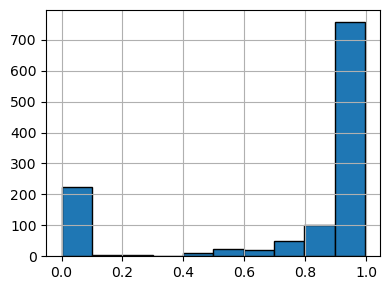

In [48]:
thresholds = list(dict_topic1_pro_threshold_h.values())
print(np.min(thresholds), np.median(thresholds),np.average(thresholds), np.max(thresholds), len(thresholds))
import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
plt.hist(thresholds,  edgecolor='black')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
dict_topic_relation_h = check_topic_relation(health_pairwise_topic_similarity, dict_topic1_pro_threshold_h)
save_to_pickle(dict_topic_relation_h, 'data/dict_topic_relation_h.pkl')

  4%|███████████▊                                                                                                                                                                                                                                                                         | 51/1194 [32:55<8:58:07, 28.25s/it]

In [ ]:
# """
# keep: 30, 31, 59, 60, 67, 74, 76, 84, 89, 96, 113, 116, 122, 125, 132, 135, 138, 147, 170, 174, 189, 219, 238, 260, 282, 293, 
# 295, 305, 316, 320, 323, 332, 335, 351, 373, 388, 396, 403, 406, 420, 428, 438, 453, 468, 470, 478, 480, 486, 500, 519, 524, 534,
# 541, 557, 562, 587, 594, 598, 621, 642, 649, 655, 659, 661, 666, 671, 682, 688, 703, 714, 715, 720, 730, 743


# """

In [ ]:
# ssh -L 8889:localhost:8889 yf2505@mi-cw888.mc.cumc.columbia.edu

## Methodological innovation

In [17]:
method_folder_path = 'Domain_Matching_Clustering_k750/750_methodology_domain_JBI'  # Update with the correct folder path
method_cluster_data = extract_clusters(method_folder_path)
print(len(method_cluster_data))
cluster_dict_abbr_m = check_abbreviation(method_cluster_data)
print(len(cluster_dict_abbr_m))

750
34


In [15]:
# for k in sorted(cluster_dict_abbr_m.keys()):
#     print(k)
#     print(cluster_dict_abbr_m[k])


In [16]:
abbr_cid_m = [10, 69, 111, 132, 180, 189, 228, 243, 291, 310, 340, 380, 387, 407, 495, 570, 589, 594, 605, 636]

print(len(abbr_cid_m))

cluster_dict_abbr_cleaned_m = remove_abbreviation(method_cluster_data, abbr_cid_m)
len(cluster_dict_abbr_cleaned_m)


20


730

In [ ]:
cluster_dict_subclusters_m = break_cluster(cluster_dict_abbr_cleaned_m)
save_to_pickle(cluster_dict_subclusters_m, 'data/cluster_dict_subclusters_m.pkl')

In [17]:
cluster_dict_subclusters_m = load_from_pickle('data/cluster_dict_subclusters_m.pkl')

In [18]:
# Example usage
file_path = "YJBIN EMAN Keywords 2011-2024YTD + SciVal Topics 2001-2024YTD - for Judith Escales.xlsx"
df_keywords = load_keywords_sheet(file_path)

dict_topic_keyword_count_m = count_papers_per_keyword(df_keywords, cluster_dict_subclusters_m, year_col="Year", keyword_col="Keywords")
save_to_pickle(dict_topic_keyword_count_m, 'data/dict_topic_keyword_count_m.pkl')

In [19]:
dict_topic_keyword_proportion_m = convert_counts_to_proportions(dict_topic_keyword_count_m)
save_to_pickle(dict_topic_keyword_proportion_m, 'data/dict_topic_keyword_proportion_m.pkl')

In [36]:
topic_names_m = topic_naming(dict_topic_keyword_proportion_m, domain='method', similarity_threshold=0, k=3)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3047/3047 [51:11<00:00,  1.01s/it]


In [37]:
# save_to_pickle(topic_names_m, 'data/topic_names_m.pkl')

In [39]:
len(set(topic_names_m.values()))

1929

In [41]:
print(len(topic_names_m))

topic_names_cleaned_m = combine_topic_w_same_name(topic_names_m)
print(len(topic_names_cleaned_m))


3047
1881


In [ ]:
original2stemmed_name_m, stemmed2original_name_m = dict_stemmed_name_original_name(topic_names_cleaned_m,  topic_names_m)


In [43]:
method_topic_name_list = list(original2stemmed_name_m.keys())
print(len(method_topic_name_list))
method_pairwise_topic_similarity = compute_pairwise_cosine_similarity(
    method_topic_name_list)
len(method_pairwise_topic_similarity)

1881
computing cosine similarity...


1768140

In [44]:
for topics, score in method_pairwise_topic_similarity.items():
    print(topics, score)
    break
    

('Neural Network Models', 'Neuroinformatics Focus') 0.41255337


In [ ]:
# dict_subset_topic1_pro_threshold_m = find_threshold_by_pct(method_pairwise_topic_similarity, n_subset_topic1=int(len(topic_names_cleaned_m)*0.1), precision=0.005)
# dict_subset_topic1_pro_threshold_m
# save_to_pickle(dict_subset_topic1_pro_threshold_m, 'data/dict_subset_topic1_pro_threshold_m.pkl')

dict_topic1_pro_threshold_m = find_threshold_by_pct(method_pairwise_topic_similarity, n_subset_topic1=len(method_topic_name_list), precision=0.005)
save_to_pickle(dict_topic1_pro_threshold_m, 'data/dict_topic1_pro_threshold_m.pkl')





 49%|████████████████████████████████████████████████████████████████████████████████▋                                                                                   | 925/1880 [53:08<51:50,  3.26s/it]

In [48]:
dict_topic1_pro_threshold_m

{'Neural Network Models': (False, 0.975),
 'Neuroinformatics Focus': (True, 0.996875),
 'Neuroscience Economics Integration': (False, 0.8),
 'Innovative modeling techniques': (True, 0.9906250000000001),
 'Data Processing Techniques': (True, 0.9468749999999999),
 'Nanotechnology Innovations': (False, 0.8),
 'Multiscale Time Analysis': (False, 0.9375),
 'Multi-modal medical imaging': (False, 0.975),
 'Advanced diagnostic techniques': (False, 0.93125),
 'Multi-class classification': (False, 0.99375),
 'Multi-granularity Analysis': (True, 0.996875),
 'Multi-factor Authentication': (True, 0.984375),
 'Multi-output algorithms': (False, 0.975),
 'Structural Variation Analysis': (False, 0.8),
 'SMS Interaction': (False, 0.99375),
 'Complex Systems Analysis': (False, 0.96875),
 'System Design Integration': (True, 0.971875),
 'Microservice Architecture Dominance': (False, 0.8),
 'Systems Biology Focus': (False, 0.9875),
 'Interface Design Focus': (False, 0.8),
 'Engineering Technologies': (False

0.80625 0.984375 0.969152986550633 1264


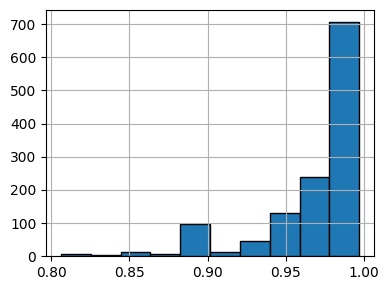

In [55]:
thresholds = dict_topic1_pro_threshold_m.values()
print(np.min(thresholds), np.median(thresholds),np.average(thresholds), np.max(thresholds), len(thresholds))
import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
plt.hist(thresholds,  edgecolor='black')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
dict_topic_relation_m = check_topic_relation(method_pairwise_topic_similarity, dict_topic1_pro_threshold_m)
save_to_pickle(dict_topic_relation_m, 'data/dict_topic_relation_m.pkl')

In [ ]:
## Run the function first block first before check topic_relation

In [ ]:
import matplotlib.pyplot as plt

# Assuming method_pairwise_topic_similarity is your dictionary
# similarity_values = list(method_pairwise_topic_similarity.values())

similarity_values = list(dict_temp.values())

# Plot the histogram
plt.figure(figsize=(8, 5))
plt.hist(similarity_values, bins=50, edgecolor='black')
plt.title("Histogram of Pairwise Cosine Similarities")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
dict_temp = {}
for topics, sim in method_pairwise_topic_similarity.items():
    # print(topic_names_m[topics_id[0]], "--", topic_names_m[topics_id[1]], sim)
    if topics[0]=='neural network model':
        dict_temp[topics] = sim

sorted_items = sorted(dict_temp.items(), key=lambda x: x[1], reverse=True)

# Print results
for (name1, name2), value in sorted_items:
    print(f"({name1}, {name2}): {value:.4f}")


In [ ]:


dict_topic_keyword_proportion_m[topic_names_cleaned_m[original2stemmed_name_m['Neural Network Models']][0]]


In [ ]:


dict_topic_keyword_proportion_m[topic_names_cleaned_m[original2stemmed_name_m['Neural Networks']][0]]
